# 🚖 RideWise  —  GNN Pipeline

In [ ]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
install('torch-geometric')
print('✅ Done')

In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os, json
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.nn import SAGEConv, GATConv
from torch_geometric.data import Data

In [4]:
warnings.filterwarnings('ignore')
os.makedirs('/kaggle/working/ridewise_artifacts', exist_ok=True)
ARTIFACT_DIR = '/kaggle/working/ridewise_artifacts'

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 📊 Load & Clean Data

In [6]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

df = pd.read_csv('/kaggle/input/datasets/yasserh/uber-fares-dataset/uber.csv')
print(f'Raw: {df.shape}')

df = df.dropna()
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True)

# ── Coordinate filters (NYC bbox)
df = df[
    df['fare_amount'].between(2.5, 150) &
    df['pickup_longitude'].between(-74.5, -72.8) &
    df['pickup_latitude'].between(40.4, 41.0) &
    df['dropoff_longitude'].between(-74.5, -72.8) &
    df['dropoff_latitude'].between(40.4, 41.0) &
    df['passenger_count'].between(1, 6)
]

# ── Distance
df['distance_km'] = haversine(
    df['pickup_latitude'].values, df['pickup_longitude'].values,
    df['dropoff_latitude'].values, df['dropoff_longitude'].values
)
df = df[df['distance_km'].between(0.1, 80)]

# ── fare_per_km outlier filter
df['fare_per_km'] = df['fare_amount'] / df['distance_km']
q1, q3 = df['fare_per_km'].quantile([0.01, 0.99])
df = df[df['fare_per_km'].between(q1, q3)].reset_index(drop=True)

print(f'Clean: {df.shape}')
print(df['fare_amount'].describe())

Raw: (200000, 9)
Clean: (187991, 11)
count    187991.000000
mean         11.272220
std           9.296399
min           2.500000
25%           6.000000
50%           8.500000
75%          12.500000
max         131.930000
Name: fare_amount, dtype: float64


## ⏰ Temporal Features

In [7]:
dt = df['pickup_datetime']
df['hour']       = dt.dt.hour
df['dow']        = dt.dt.dayofweek
df['month']      = dt.dt.month
df['is_weekend'] = (df['dow'] >= 5).astype(float)

# Peak type: 2=rush, 1=night, 0=normal
def peak(h):
    if 7 <= h <= 9 or 17 <= h <= 20: return 2
    if h >= 22 or h <= 5: return 1
    return 0
df['peak_type'] = df['hour'].apply(peak).astype(float)

# Cyclical
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['dow_sin']  = np.sin(2*np.pi*df['dow']/7)
df['dow_cos']  = np.cos(2*np.pi*df['dow']/7)
df['mon_sin']  = np.sin(2*np.pi*df['month']/12)
df['mon_cos']  = np.cos(2*np.pi*df['month']/12)

print('✅ Features added')

✅ Features added


## 🗺️ Spatial Discretization — KMeans Zones

In [8]:
N_ZONES = 100  # Reduced from 150 to ensure denser edges and better generalization

all_coords = np.vstack([
    df[['pickup_latitude','pickup_longitude']].values,
    df[['dropoff_latitude','dropoff_longitude']].values
])

print(f'Fitting KMeans({N_ZONES})...')
kmeans = KMeans(n_clusters=N_ZONES, random_state=SEED, n_init=10, max_iter=300)
kmeans.fit(all_coords)

df['pu_zone'] = kmeans.predict(df[['pickup_latitude','pickup_longitude']].values)
df['do_zone'] = kmeans.predict(df[['dropoff_latitude','dropoff_longitude']].values)

# Remove same-zone rides (very short trips causing noise)
df = df[df['pu_zone'] != df['do_zone']].reset_index(drop=True)

zone_centers = pd.DataFrame(kmeans.cluster_centers_, columns=['lat','lon'])
zone_centers['zone_id'] = range(N_ZONES)

print(f'After zone filter: {len(df)} rides')
print(f'Unique routes: {df.groupby(["pu_zone","do_zone"]).ngroups}')

joblib.dump(kmeans, f'{ARTIFACT_DIR}/kmeans_zones.pkl')
zone_centers.to_csv(f'{ARTIFACT_DIR}/zone_centers.csv', index=False)
print('✅ Zones created and saved')

Fitting KMeans(100)...
After zone filter: 183365 rides
Unique routes: 5706
✅ Zones created and saved


## 🔀 Train/Val/Test Split — AT THE RIDE LEVEL

In [9]:
# Split at ride level
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 128,355 | Val: 27,505 | Test: 27,505


## 🔗 Graph Construction (from TRAIN only)

In [10]:
def build_node_features_from_train(train_df, n_zones, zone_centers):
    """
    Node features computed ONLY from training data.
    No leakage from val/test.
    """
    pu_stats = train_df.groupby('pu_zone').agg(
        avg_fare        = ('fare_amount', 'mean'),
        ride_count      = ('fare_amount', 'count'),
        avg_distance    = ('distance_km', 'mean'),
        avg_fare_per_km = ('fare_per_km', 'mean'),
        avg_passengers  = ('passenger_count', 'mean'),
        peak_ratio      = ('peak_type', lambda x: (x==2).mean()),
        night_ratio     = ('peak_type', lambda x: (x==1).mean()),
        weekend_ratio   = ('is_weekend', 'mean'),
    ).reset_index().rename(columns={'pu_zone':'zone'})

    do_stats = train_df.groupby('do_zone').agg(
        do_count     = ('fare_amount', 'count'),
        do_avg_fare  = ('fare_amount', 'mean'),
    ).reset_index().rename(columns={'do_zone':'zone'})

    all_zones = pd.DataFrame({'zone': range(n_zones)})
    stats = all_zones \
        .merge(pu_stats, on='zone', how='left') \
        .merge(do_stats, on='zone', how='left') \
        .merge(zone_centers.rename(columns={'zone_id':'zone','lat':'z_lat','lon':'z_lon'}),
               on='zone', how='left') \
        .fillna(0)

    feat_cols = ['avg_fare','ride_count','avg_distance','avg_fare_per_km',
                 'avg_passengers','peak_ratio','night_ratio','weekend_ratio',
                 'do_count','do_avg_fare','z_lat','z_lon']
    return stats[feat_cols].values.astype(np.float32), feat_cols

node_feats_raw, node_feat_cols = build_node_features_from_train(train_df, N_ZONES, zone_centers)
print(f'Node feature matrix: {node_feats_raw.shape}')

Node feature matrix: (100, 12)


In [ ]:
# ── Build ride-level edge features ──
# Each individual ride = one training sample with its own edge features

RIDE_FEAT_COLS = [
    'distance_km', 'passenger_count', 'fare_per_km',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'mon_sin', 'mon_cos',
    'peak_type', 'is_weekend'
]

def build_graph_data(subset_df, node_feats_scaled, node_scaler, edge_scaler=None,
                     label_scaler=None, fit_scalers=False):
    """
    Build a PyG Data object from a dataframe of rides.
    Each ride is an edge in the graph.
    """
    src = torch.tensor(subset_df['pu_zone'].values, dtype=torch.long)
    dst = torch.tensor(subset_df['do_zone'].values, dtype=torch.long)
    edge_index = torch.stack([src, dst], dim=0)

    X_edge_raw = subset_df[RIDE_FEAT_COLS].values.astype(np.float32)
    y_raw      = subset_df['fare_amount'].values.astype(np.float32)

    if fit_scalers:
        edge_scaler  = StandardScaler().fit(X_edge_raw)
        label_scaler = StandardScaler().fit(y_raw.reshape(-1,1))

    X_edge = torch.tensor(edge_scaler.transform(X_edge_raw), dtype=torch.float32)
    y      = torch.tensor(
        label_scaler.transform(y_raw.reshape(-1,1)).flatten(),
        dtype=torch.float32
    )

    X_node = torch.tensor(node_feats_scaled, dtype=torch.float32)

    data = Data(
        x          = X_node,
        edge_index = edge_index,
        edge_attr  = X_edge,
        y          = y,
        y_raw      = torch.tensor(y_raw, dtype=torch.float32)
    )
    if fit_scalers:
        return data, edge_scaler, label_scaler
    return data

# Scale node features on train only
node_scaler = StandardScaler().fit(node_feats_raw)
node_feats_scaled = node_scaler.transform(node_feats_raw)

# Build train data, fit edge/label scalers on train
train_data, edge_scaler, label_scaler = build_graph_data(
    train_df, node_feats_scaled, node_scaler, fit_scalers=True
)

# Build val/test with same scalers
val_data  = build_graph_data(val_df,  node_feats_scaled, node_scaler, edge_scaler, label_scaler)
test_data = build_graph_data(test_df, node_feats_scaled, node_scaler, edge_scaler, label_scaler)

# Save scalers
joblib.dump(node_scaler,  f'{ARTIFACT_DIR}/node_scaler.pkl')
joblib.dump(edge_scaler,  f'{ARTIFACT_DIR}/edge_scaler.pkl')
joblib.dump(label_scaler, f'{ARTIFACT_DIR}/label_scaler.pkl')

print(f'Train edges (rides): {train_data.edge_index.shape[1]:,}')
print(f'Val   edges (rides): {val_data.edge_index.shape[1]:,}')
print(f'Test  edges (rides): {test_data.edge_index.shape[1]:,}')
print(f'Node features: {train_data.x.shape[1]}')
print(f'Edge features: {train_data.edge_attr.shape[1]}')
print(f'Label mean (train): {label_scaler.mean_[0]:.2f} | std: {label_scaler.scale_[0]:.2f}')

Train edges (rides): 128,355
Val   edges (rides): 27,505
Test  edges (rides): 27,505
Node features: 12
Edge features: 11
Label mean (train): 11.43 | std: 9.34


## 🤖 GNN Model — Improved Architecture

In [12]:
class RideWiseGNN(nn.Module):
    """
    GraphSAGE + GAT hybrid for per-ride fare prediction.
    
    Key design:
    - Node embeddings capture zone-level context (demand, avg fare, etc.)
    - Edge features capture per-ride specifics (distance, time, passengers)
    - Prediction head combines both: f(src_emb, dst_emb, edge_feat)
    """
    def __init__(self, node_in, edge_in, hidden=128, gat_out=64, heads=4, dropout=0.2):
        super().__init__()

        # Node feature encoder
        self.node_enc = nn.Sequential(
            nn.Linear(node_in, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Graph layers
        self.sage1 = SAGEConv(hidden, hidden, aggr='mean')
        self.sage2 = SAGEConv(hidden, hidden, aggr='mean')
        self.gat   = GATConv(hidden, gat_out // heads, heads=heads,
                              dropout=dropout, concat=True, add_self_loops=True)

        self.ln1 = nn.LayerNorm(hidden)
        self.ln2 = nn.LayerNorm(hidden)
        self.ln3 = nn.LayerNorm(gat_out)

        # Edge feature encoder
        self.edge_enc = nn.Sequential(
            nn.Linear(edge_in, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU()
        )

        # Prediction head: src_emb + dst_emb + edge_emb → fare
        head_in = gat_out + gat_out + hidden // 2
        self.head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

        self.drop = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def encode_nodes(self, x, edge_index):
        h = self.node_enc(x)
        h = self.ln1(F.gelu(self.sage1(h, edge_index)) + h)
        h = self.drop(h)
        h = self.ln2(F.gelu(self.sage2(h, edge_index)) + h)
        h = self.drop(h)
        h = self.ln3(F.elu(self.gat(h, edge_index)))
        return h  # [N_zones, gat_out]

    def forward(self, x, edge_index, edge_attr):
        node_emb  = self.encode_nodes(x, edge_index)    # [N, D_node]
        edge_emb  = self.edge_enc(edge_attr)             # [E, D_edge]

        src, dst  = edge_index
        combined  = torch.cat([node_emb[src], node_emb[dst], edge_emb], dim=-1)
        return self.head(combined).squeeze(-1), node_emb


model = RideWiseGNN(
    node_in = train_data.x.shape[1],
    edge_in = train_data.edge_attr.shape[1],
    hidden  = 128,
    gat_out = 64,
    heads   = 4,
    dropout = 0.2
).to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 177,921


## 📉 Training — Batched by Ride

In [13]:
# ── Move data to device ──
X_node   = train_data.x.to(device)
y_train  = train_data.y.to(device)
y_train_raw = train_data.y_raw.to(device)
ei_train = train_data.edge_index.to(device)
ea_train = train_data.edge_attr.to(device)

X_node_v  = val_data.x.to(device)
y_val     = val_data.y.to(device)
y_val_raw = val_data.y_raw.to(device)
ei_val    = val_data.edge_index.to(device)
ea_val    = val_data.edge_attr.to(device)

X_node_t   = test_data.x.to(device)
y_test     = test_data.y.to(device)
y_test_raw = test_data.y_raw.to(device)
ei_test    = test_data.edge_index.to(device)
ea_test    = test_data.edge_attr.to(device)

# ── IMPORTANT: shared node features across splits ──
# The SAME node feature matrix is used for all splits.
# The edge_index per split only contains that split's rides.
# This way: node aggregation is learned from the global graph structure,
# but predictions are made only on that split's edges.

# ── Batched training: mini-batch on edges ──
BATCH_SIZE = 4096
n_train = ei_train.shape[1]

def get_batches(n, batch_size, shuffle=True):
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    return [idx[i:i+batch_size] for i in range(0, n, batch_size)]

# ── Loss ──
# Huber loss in normalized label space
criterion = nn.HuberLoss(delta=1.0)

# ── Optimizer: AdamW with weight decay ──
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

# ── Scheduler: cosine annealing ──
EPOCHS = 80
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

def evaluate_split(X_node, edge_index, edge_attr, y_scaled, y_dollar_true):
    model.eval()
    with torch.no_grad():
        preds_scaled, _ = model(X_node, edge_index, edge_attr)
        loss = criterion(preds_scaled, y_scaled).item()

        # Inverse transform to dollars
        p_np = preds_scaled.cpu().numpy().reshape(-1,1)
        p_dollar = label_scaler.inverse_transform(p_np).flatten()
        y_dollar = y_dollar_true.cpu().numpy()

        mae  = mean_absolute_error(y_dollar, p_dollar)
        rmse = np.sqrt(mean_squared_error(y_dollar, p_dollar))
        r2   = r2_score(y_dollar, p_dollar)
    return loss, mae, rmse, r2, p_dollar

print('Starting training...')
best_val_mae = float('inf')
best_epoch   = 0
patience_ctr = 0
PATIENCE     = 20

history = {'train_loss':[], 'val_loss':[], 'train_mae':[], 'val_mae':[], 'val_r2':[]}

for epoch in range(1, EPOCHS+1):
    model.train()
    batches    = get_batches(n_train, BATCH_SIZE, shuffle=True)
    epoch_loss = 0.0

    for batch_idx in batches:
        # Mini-batch: only the edges in this batch
        # Node embeddings still computed over the FULL graph for proper message passing
        optimizer.zero_grad()

        preds, _ = model(X_node, ei_train, ea_train)
        # Only compute loss on this mini-batch of edges
        loss = criterion(preds[batch_idx], y_train[batch_idx])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        break  # Full-batch (not mini-batch) for GNN correctness
        # Note: true mini-batching in GNN needs NeighborSampler;
        # for this dataset size, full-batch is feasible on GPU

    # Full-batch training step
    model.train()
    optimizer.zero_grad()
    preds_tr, _ = model(X_node, ei_train, ea_train)
    loss_tr = criterion(preds_tr, y_train)
    loss_tr.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    # Evaluate
    tr_loss, tr_mae, tr_rmse, tr_r2, _ = evaluate_split(X_node, ei_train, ea_train, y_train, y_train_raw)
    vl_loss, vl_mae, vl_rmse, vl_r2, _ = evaluate_split(X_node_v, ei_val, ea_val, y_val, y_val_raw)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_mae'].append(tr_mae)
    history['val_mae'].append(vl_mae)
    history['val_r2'].append(vl_r2)

    if vl_mae < best_val_mae:
        best_val_mae = vl_mae
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), f'{ARTIFACT_DIR}/best_model.pt')
    else:
        patience_ctr += 1

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'Ep {epoch:3d} | '
              f'Train Loss={tr_loss:.4f} MAE=${tr_mae:.2f} | '
              f'Val Loss={vl_loss:.4f} MAE=${vl_mae:.2f} R²={vl_r2:.3f} | '
              f'LR={lr:.2e}')

    if patience_ctr >= PATIENCE:
        print(f'Early stop at epoch {epoch} (best val MAE=${best_val_mae:.2f} at epoch {best_epoch})')
        break

print(f'\n✅ Training done. Best epoch: {best_epoch}, best val MAE: ${best_val_mae:.2f}')

Starting training...
Ep   1 | Train Loss=0.3450 MAE=$5.70 | Val Loss=0.3484 MAE=$5.73 R²=-0.276 | LR=3.00e-04
Ep  10 | Train Loss=0.2175 MAE=$4.18 | Val Loss=0.2205 MAE=$4.21 R²=0.246 | LR=2.89e-04
Ep  20 | Train Loss=0.1047 MAE=$2.88 | Val Loss=0.1059 MAE=$2.90 R²=0.711 | LR=2.58e-04
Ep  30 | Train Loss=0.0703 MAE=$2.44 | Val Loss=0.0708 MAE=$2.44 R²=0.822 | LR=2.10e-04
Ep  40 | Train Loss=0.0607 MAE=$2.27 | Val Loss=0.0623 MAE=$2.28 R²=0.847 | LR=1.55e-04
Ep  50 | Train Loss=0.0538 MAE=$2.13 | Val Loss=0.0549 MAE=$2.14 R²=0.868 | LR=9.95e-05
Ep  60 | Train Loss=0.0497 MAE=$2.06 | Val Loss=0.0509 MAE=$2.07 R²=0.877 | LR=5.25e-05
Ep  70 | Train Loss=0.0482 MAE=$2.02 | Val Loss=0.0494 MAE=$2.03 R²=0.881 | LR=2.10e-05
Ep  80 | Train Loss=0.0478 MAE=$2.00 | Val Loss=0.0491 MAE=$2.01 R²=0.882 | LR=1.00e-05

✅ Training done. Best epoch: 80, best val MAE: $2.01


📊 FINAL TEST RESULTS
MAE:  $2.02
RMSE: $3.12
R²:    0.8889


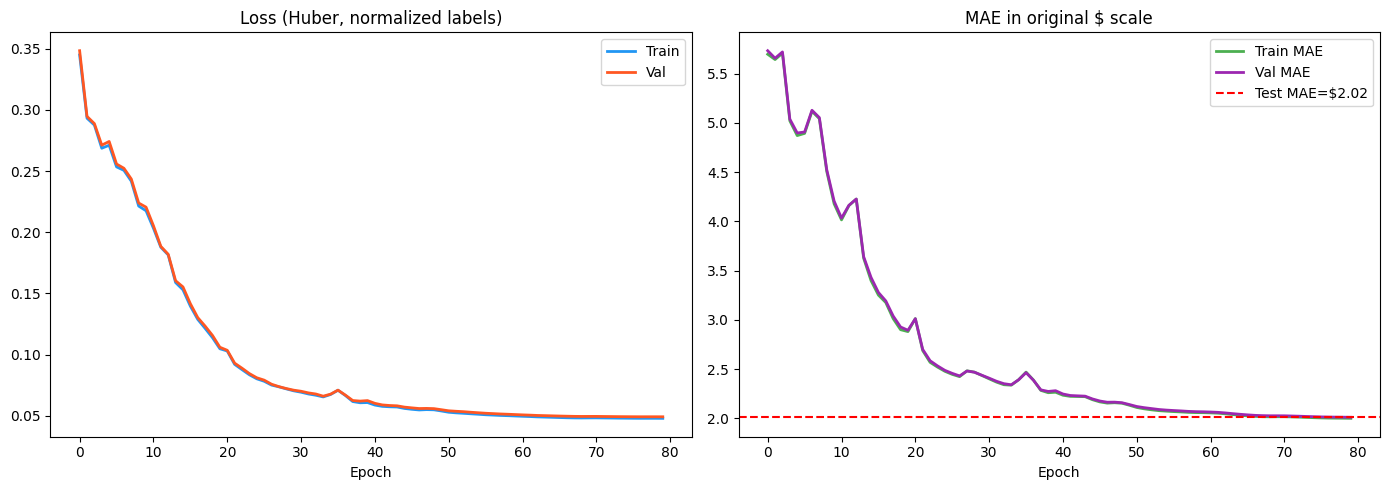

In [14]:
# Load best and evaluate on test
model.load_state_dict(torch.load(f'{ARTIFACT_DIR}/best_model.pt'))
te_loss, te_mae, te_rmse, te_r2, te_preds = evaluate_split(
    X_node_t, ei_test, ea_test, y_test, y_test_raw
)

print('='*55)
print('📊 FINAL TEST RESULTS')
print('='*55)
print(f'MAE:  ${te_mae:.2f}')
print(f'RMSE: ${te_rmse:.2f}')
print(f'R²:    {te_r2:.4f}')
print('='*55)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train', color='#2196F3', lw=2)
axes[0].plot(history['val_loss'],   label='Val',   color='#FF5722', lw=2)
axes[0].set_title('Loss (Huber, normalized labels)')
axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_mae'], label='Train MAE', color='#4CAF50', lw=2)
axes[1].plot(history['val_mae'],   label='Val MAE',   color='#9C27B0', lw=2)
axes[1].axhline(te_mae, color='red', ls='--', lw=1.5, label=f'Test MAE=${te_mae:.2f}')
axes[1].set_title('MAE in original $ scale')
axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/training_curves.png', dpi=150)
plt.show()

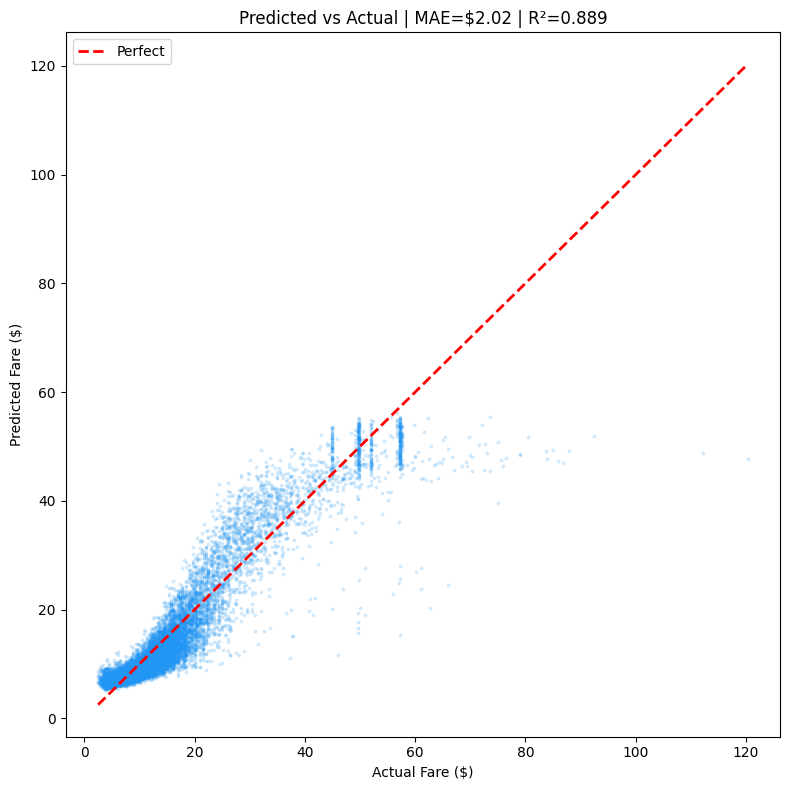

In [15]:
# Predicted vs Actual
y_true_test = y_test_raw.cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_true_test, te_preds, alpha=0.15, s=3, c='#2196F3', rasterized=True)
lo = min(y_true_test.min(), te_preds.min())
hi = max(y_true_test.max(), te_preds.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect')
ax.set_xlabel('Actual Fare ($)'); ax.set_ylabel('Predicted Fare ($)')
ax.set_title(f'Predicted vs Actual | MAE=${te_mae:.2f} | R²={te_r2:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/pred_vs_actual.png', dpi=150)
plt.show()

## ⚖️ Fairness Engine

In [16]:
# Run on the full dataset for fairness analysis
model.eval()

# Build full-data graph
full_data = build_graph_data(df, node_feats_scaled, node_scaler, edge_scaler, label_scaler)
X_node_f  = full_data.x.to(device)
ei_full   = full_data.edge_index.to(device)
ea_full   = full_data.edge_attr.to(device)

with torch.no_grad():
    preds_all_scaled, node_embs = model(X_node_f, ei_full, ea_full)
    preds_all_dollar = label_scaler.inverse_transform(
        preds_all_scaled.cpu().numpy().reshape(-1,1)
    ).flatten()

# Build fairness dataframe
fairness_df = df[['pu_zone','do_zone','fare_amount','distance_km',
                   'passenger_count','hour','peak_type','is_weekend']].copy()
fairness_df['predicted_fare'] = preds_all_dollar
fairness_df['deviation'] = (
    (fairness_df['fare_amount'] - fairness_df['predicted_fare'])
    / (fairness_df['predicted_fare'].abs() + 1e-6)
)

def classify(d):
    if d > 0.20: return 'Overpriced'
    if d < -0.20: return 'Underpriced'
    return 'Fair'

def fscore(d): return round(max(0, min(100, 100 - abs(d)*100)), 1)

fairness_df['fairness_label'] = fairness_df['deviation'].apply(classify)
fairness_df['fairness_score'] = fairness_df['deviation'].apply(fscore)

print('=== Fairness Distribution ===')
print(fairness_df['fairness_label'].value_counts())
print(f'\nAvg fairness score: {fairness_df["fairness_score"].mean():.1f}/100')

fairness_df.to_csv(f'{ARTIFACT_DIR}/fairness_results.csv', index=False)

=== Fairness Distribution ===
fairness_label
Fair           111806
Underpriced     41271
Overpriced      30288
Name: count, dtype: int64

Avg fairness score: 81.4/100


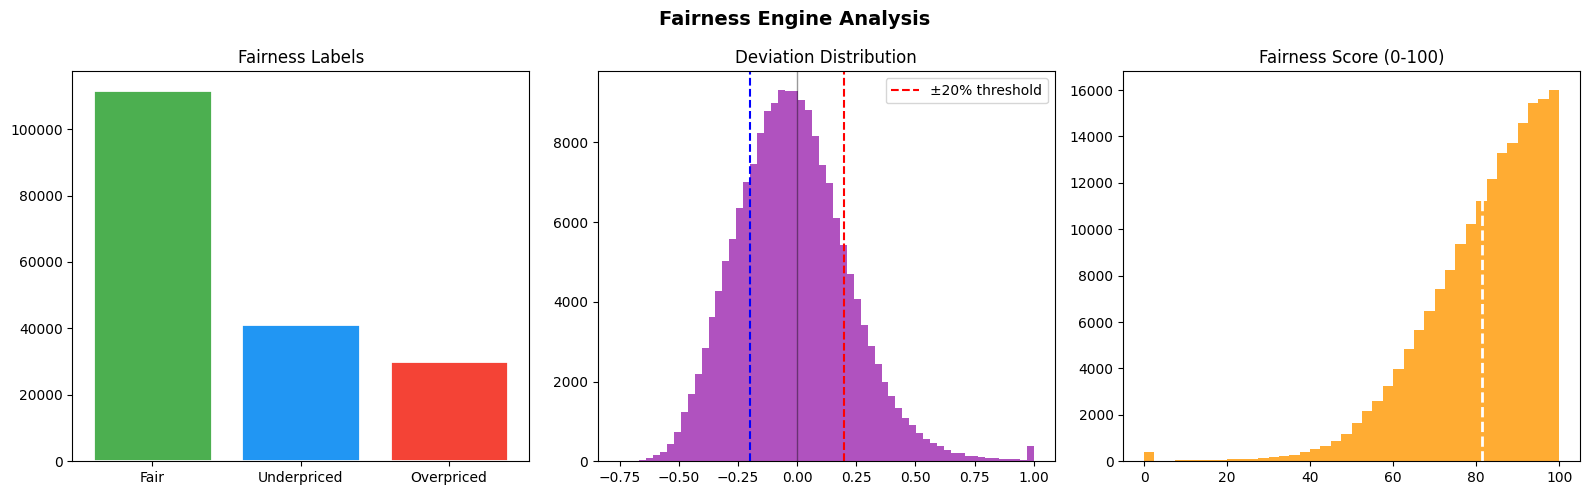

In [17]:
# Fairness plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fairness Engine Analysis', fontweight='bold', fontsize=14)

colors = {'Fair':'#4CAF50','Overpriced':'#F44336','Underpriced':'#2196F3'}
counts = fairness_df['fairness_label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[colors[c] for c in counts.index], edgecolor='white', lw=2)
axes[0].set_title('Fairness Labels')

axes[1].hist(fairness_df['deviation'].clip(-1,1), bins=60, color='#9C27B0', alpha=0.8, edgecolor='none')
axes[1].axvline(0.20,  color='red',   ls='--', lw=1.5, label='±20% threshold')
axes[1].axvline(-0.20, color='blue',  ls='--', lw=1.5)
axes[1].axvline(0,     color='black', ls='-',  lw=1,   alpha=0.4)
axes[1].set_title('Deviation Distribution'); axes[1].legend()

axes[2].hist(fairness_df['fairness_score'], bins=40, color='#FF9800', alpha=0.8, edgecolor='none')
axes[2].axvline(fairness_df['fairness_score'].mean(), color='white', ls='--', lw=2)
axes[2].set_title('Fairness Score (0-100)')

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/fairness_analysis.png', dpi=150)
plt.show()

## 🔍 Explainability

=== Sample Explanation ===
  Distance (km)         :  72.8%
  Fare/km Signal        :  10.8%
  Month (sin)           :   7.5%
  Peak Hour             :   3.0%
  Hour (cos)            :   2.2%
  Month (cos)           :   1.5%
  Passengers            :   1.4%
  Hour (sin)            :   0.5%
  Weekend               :   0.2%
  Day of Week (cos)     :   0.1%
  Day of Week (sin)     :   0.0%


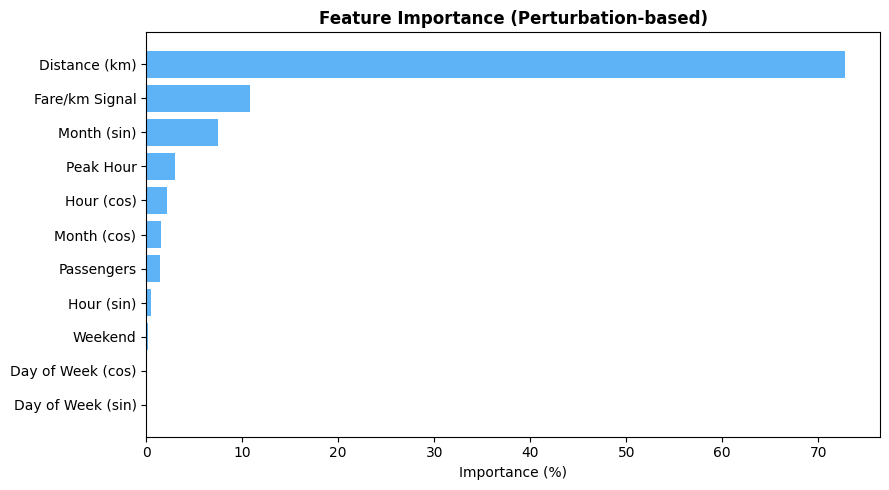

In [18]:
def explain_edge_perturbation(model, X_node, edge_index, edge_attr, edge_pos,
                              feat_names, label_scaler, device, n=1):
    """
    Feature importance via perturbation on edge features.
    Zeros out each feature and measures the dollar-change in prediction.
    """
    model.eval()
    readable = {
        'distance_km':      'Distance (km)',
        'passenger_count':  'Passengers',
        'fare_per_km':      'Fare/km Signal',
        'hour_sin':         'Hour (sin)',
        'hour_cos':         'Hour (cos)',
        'dow_sin':          'Day of Week (sin)',
        'dow_cos':          'Day of Week (cos)',
        'mon_sin':          'Month (sin)',
        'mon_cos':          'Month (cos)',
        'peak_type':        'Peak Hour',
        'is_weekend':       'Weekend',
    }

    with torch.no_grad():
        base_preds, _ = model(X_node, edge_index, edge_attr)
        base_scaled   = base_preds[edge_pos].item()
        base_dollar   = label_scaler.inverse_transform([[base_scaled]])[0][0]

    importances = {}
    for i, col in enumerate(feat_names):
        ea_perturbed = edge_attr.clone()
        ea_perturbed[:, i] = 0.0
        with torch.no_grad():
            p_perturbed, _ = model(X_node, edge_index, ea_perturbed)
            p_dollar = label_scaler.inverse_transform([[p_perturbed[edge_pos].item()]])[0][0]
        delta = abs(base_dollar - p_dollar)
        importances[readable.get(col, col)] = delta

    total = sum(importances.values()) + 1e-8
    return {k: round(v/total*100, 1) for k, v in importances.items()}

# Demonstrate on a sample edge
sample_pos = 100
imp = explain_edge_perturbation(
    model, X_node_f, ei_full, ea_full,
    edge_pos=sample_pos,
    feat_names=RIDE_FEAT_COLS,
    label_scaler=label_scaler,
    device=device
)

print('=== Sample Explanation ===')
for k, v in sorted(imp.items(), key=lambda x: -x[1]):
    print(f'  {k:<22}: {v:>5.1f}%')

fig, ax = plt.subplots(figsize=(9,5))
sorted_imp = dict(sorted(imp.items(), key=lambda x: x[1]))
ax.barh(list(sorted_imp.keys()), list(sorted_imp.values()), color='#42A5F5', alpha=0.85)
ax.set_title('Feature Importance (Perturbation-based)', fontweight='bold')
ax.set_xlabel('Importance (%)')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/feature_importance.png', dpi=150)
plt.show()

## 🔄 Counterfactual Engine

In [19]:
def predict_single_ride(model, kmeans, node_feats_scaled, node_scaler, 
                        edge_scaler, label_scaler, device,
                        pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
                        hour, dow, passengers, peak_type, is_weekend):
    """
    Predict fare for a single new ride without rebuilding the full graph.
    Uses the trained node embeddings + per-ride edge features.
    """
    import math

    def hav(la1,lo1,la2,lo2):
        R=6371; la1,lo1,la2,lo2=map(math.radians,[la1,lo1,la2,lo2])
        dlat,dlon=la2-la1,lo2-lo1
        a=math.sin(dlat/2)**2+math.cos(la1)*math.cos(la2)*math.sin(dlon/2)**2
        return 2*R*math.asin(math.sqrt(a))

    dist = hav(pickup_lat, pickup_lon, dropoff_lat, dropoff_lon)
    fare_per_km_est = 2.5 + (0.8 if peak_type == 2 else 0)

    pu_zone = int(kmeans.predict([[pickup_lat, pickup_lon]])[0])
    do_zone = int(kmeans.predict([[dropoff_lat, dropoff_lon]])[0])

    # Edge features
    ef_raw = np.array([[
        dist, float(passengers), fare_per_km_est,
        np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24),
        np.sin(2*np.pi*dow/7),   np.cos(2*np.pi*dow/7),
        np.sin(2*np.pi*1/12),    np.cos(2*np.pi*1/12),  # month=1 default
        float(peak_type), float(is_weekend)
    ]], dtype=np.float32)

    ef_scaled = edge_scaler.transform(ef_raw)

    # Build minimal graph: just this one edge, but all nodes
    # Node embeddings are shared
    X_node = torch.tensor(node_feats_scaled, dtype=torch.float32).to(device)
    edge_index = torch.tensor([[pu_zone],[do_zone]], dtype=torch.long).to(device)
    edge_attr  = torch.tensor(ef_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        # Need full graph for proper SAGE aggregation → use full graph node emb
        # but predict on this single edge
        node_emb = model.encode_nodes(X_node, 
                                       torch.tensor([[pu_zone],[do_zone]], dtype=torch.long).to(device))
        edge_emb = model.edge_enc(edge_attr)
        src_emb  = node_emb[0:1]
        dst_emb  = node_emb[1:2] if pu_zone != do_zone else node_emb[0:1]
        combined = torch.cat([src_emb, dst_emb, edge_emb], dim=-1)
        pred_scaled = model.head(combined).squeeze().item()
        pred_dollar = float(label_scaler.inverse_transform([[pred_scaled]])[0][0])

    return max(2.5, pred_dollar), pu_zone, do_zone, dist


def generate_counterfactuals(model, kmeans, node_feats_scaled, node_scaler,
                              edge_scaler, label_scaler, device,
                              pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
                              hour, dow, passengers, current_fare):
    """Generate alternative scenarios"""
    scenarios = []

    def get_peak(h):
        if 7<=h<=9 or 17<=h<=20: return 2
        if h>=22 or h<=5: return 1
        return 0

    current_peak = get_peak(hour)

    # Time alternatives
    for dh in [-3, -2, -1, 1, 2, 3]:
        alt_h = (hour + dh) % 24
        alt_peak = get_peak(alt_h)
        if alt_peak < current_peak:
            try:
                alt_fare, _, _, _ = predict_single_ride(
                    model, kmeans, node_feats_scaled, node_scaler, edge_scaler, label_scaler, device,
                    pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
                    alt_h, dow, passengers, alt_peak, dow>=5
                )
                savings = current_fare - alt_fare
                if savings > 0.5:
                    scenarios.append({
                        'type': '⏰ Time Change',
                        'suggestion': f'Leave at {alt_h:02d}:00 instead of {hour:02d}:00 (less busy)',
                        'estimated_fare': round(alt_fare, 2),
                        'savings': round(savings, 2)
                    })
            except: pass

    # Nearby pickup zones
    pu_center = kmeans.cluster_centers_[int(kmeans.predict([[pickup_lat, pickup_lon]])[0])]
    zone_dists = np.linalg.norm(kmeans.cluster_centers_ - pu_center, axis=1)
    nearby_pus = np.argsort(zone_dists)[1:4]
    for alt_zone in nearby_pus:
        alt_lat, alt_lon = kmeans.cluster_centers_[alt_zone]
        try:
            alt_fare, _, _, _ = predict_single_ride(
                model, kmeans, node_feats_scaled, node_scaler, edge_scaler, label_scaler, device,
                alt_lat, alt_lon, dropoff_lat, dropoff_lon,
                hour, dow, passengers, current_peak, dow>=5
            )
            savings = current_fare - alt_fare
            if savings > 1.0:
                scenarios.append({
                    'type': '📍 Nearby Pickup',
                    'suggestion': f'Walk ~{int(zone_dists[alt_zone]*111*1000)}m to a cheaper pickup zone',
                    'estimated_fare': round(alt_fare, 2),
                    'savings': round(savings, 2)
                })
        except: pass

    # Ride pooling
    if passengers <= 3:
        pool_fare = current_fare * 0.70
        scenarios.append({
            'type': '🤝 Ride Share',
            'suggestion': 'Try UberPool — share ride, split cost',
            'estimated_fare': round(pool_fare, 2),
            'savings': round(current_fare - pool_fare, 2)
        })

    return sorted(scenarios, key=lambda x: -x['savings'])[:5]


# Test counterfactuals
test_ride = df.iloc[500]
base_fare, puz, doz, dist = predict_single_ride(
    model, kmeans, node_feats_scaled, node_scaler, edge_scaler, label_scaler, device,
    test_ride['pickup_latitude'], test_ride['pickup_longitude'],
    test_ride['dropoff_latitude'], test_ride['dropoff_longitude'],
    hour=17, dow=1, passengers=1, peak_type=2, is_weekend=False
)

cfs = generate_counterfactuals(
    model, kmeans, node_feats_scaled, node_scaler, edge_scaler, label_scaler, device,
    test_ride['pickup_latitude'], test_ride['pickup_longitude'],
    test_ride['dropoff_latitude'], test_ride['dropoff_longitude'],
    hour=17, dow=1, passengers=1, current_fare=base_fare
)

print(f'Current fare: ${base_fare:.2f} | Actual: ${test_ride["fare_amount"]:.2f}')
for cf in cfs:
    print(f"  {cf['type']}: {cf['suggestion']} → ${cf['estimated_fare']:.2f} (save ${cf['savings']:.2f})")

Current fare: $12.60 | Actual: $9.30
  🤝 Ride Share: Try UberPool — share ride, split cost → $8.82 (save $3.78)
  ⏰ Time Change: Leave at 16:00 instead of 17:00 (less busy) → $10.69 (save $1.91)
  ⏰ Time Change: Leave at 15:00 instead of 17:00 (less busy) → $11.11 (save $1.49)
  📍 Nearby Pickup: Walk ~858m to a cheaper pickup zone → $11.30 (save $1.30)
  ⏰ Time Change: Leave at 14:00 instead of 17:00 (less busy) → $11.56 (save $1.04)


## 📊 Graph Insights

=== SYSTEM INSIGHTS ===
Total rides analyzed: 183,365
Fare Gini:            0.3547
Peak hour premium:    +-4.7%


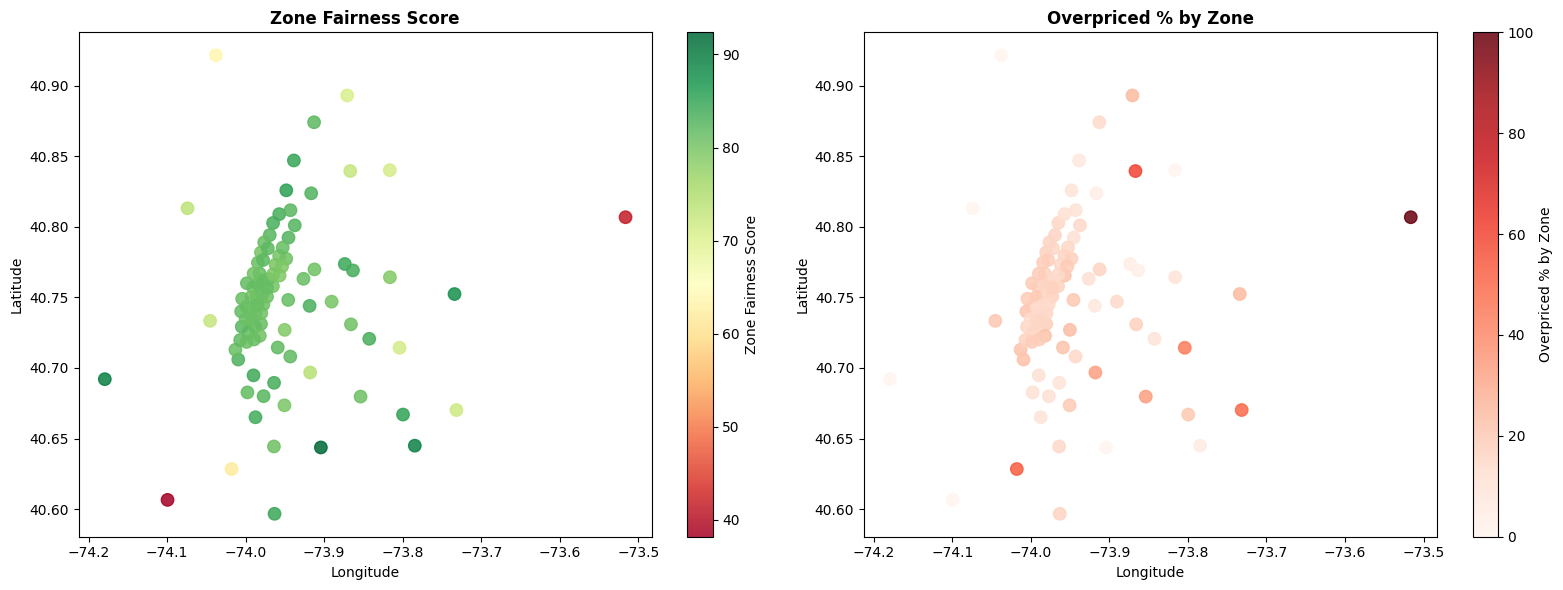

✅ Zone stats saved


In [20]:
# Zone-level fairness aggregation
zone_stats = fairness_df.groupby('pu_zone').agg(
    avg_fare        = ('fare_amount',     'mean'),
    avg_pred        = ('predicted_fare',  'mean'),
    avg_fairness    = ('fairness_score',  'mean'),
    pct_overpriced  = ('fairness_label',  lambda x: (x=='Overpriced').mean()*100),
    ride_count      = ('fare_amount',     'count')
).reset_index().merge(
    zone_centers.rename(columns={'zone_id':'pu_zone','lat':'z_lat','lon':'z_lon'}),
    on='pu_zone', how='left'
)

# Gini
def gini(a):
    a = np.sort(a)
    n = len(a)
    idx = np.arange(1, n+1)
    return (2*np.sum(idx*a) - (n+1)*np.sum(a)) / (n*np.sum(a)+1e-8)

print('=== SYSTEM INSIGHTS ===')
print(f'Total rides analyzed: {len(fairness_df):,}')
print(f'Fare Gini:            {gini(df["fare_amount"].values):.4f}')
print(f'Peak hour premium:    +{(df[df["peak_type"]==2]["fare_amount"].mean() / df[df["peak_type"]==0]["fare_amount"].mean() - 1)*100:.1f}%')

# Maps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, title, cmap in zip(
    axes,
    ['avg_fairness', 'pct_overpriced'],
    ['Zone Fairness Score', 'Overpriced % by Zone'],
    ['RdYlGn', 'Reds']
):
    sc = ax.scatter(zone_stats['z_lon'], zone_stats['z_lat'],
                    c=zone_stats[col], cmap=cmap, s=80, alpha=0.85)
    plt.colorbar(sc, ax=ax, label=title)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/zone_fairness_map.png', dpi=150)
plt.show()

zone_stats.to_csv(f'{ARTIFACT_DIR}/zone_stats.csv', index=False)
print('✅ Zone stats saved')

## 💾 Save All Artifacts

In [21]:
# Model config
config = {
    'node_in':       int(train_data.x.shape[1]),
    'edge_in':       int(train_data.edge_attr.shape[1]),
    'hidden':        128,
    'gat_out':       64,
    'heads':         4,
    'dropout':       0.2,
    'n_zones':       N_ZONES,
    'node_feat_cols': node_feat_cols,
    'edge_feat_cols': RIDE_FEAT_COLS
}
with open(f'{ARTIFACT_DIR}/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Node features scaled
np.save(f'{ARTIFACT_DIR}/node_feats_scaled.npy', node_feats_scaled)

# Edge data for counterfactual engine
edge_agg = df.groupby(['pu_zone','do_zone']).agg(
    avg_fare     = ('fare_amount',  'mean'),
    avg_distance = ('distance_km',  'mean'),
    ride_count   = ('fare_amount',  'count')
).reset_index()
edge_agg.to_csv(f'{ARTIFACT_DIR}/edge_data.csv', index=False)

# Summary stats
summary = {
    'total_rides':       int(len(df)),
    'n_zones':           N_ZONES,
    'n_routes':          int(edge_agg.shape[0]),
    'avg_fare':          float(df['fare_amount'].mean()),
    'test_mae':          float(te_mae),
    'test_rmse':         float(te_rmse),
    'test_r2':           float(te_r2),
    'pct_overpriced':    float((fairness_df['fairness_label']=='Overpriced').mean()*100),
    'pct_fair':          float((fairness_df['fairness_label']=='Fair').mean()*100),
    'pct_underpriced':   float((fairness_df['fairness_label']=='Underpriced').mean()*100),
    'gini_coefficient':  float(gini(df['fare_amount'].values))
}
with open(f'{ARTIFACT_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ All artifacts saved:')
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    sz = os.path.getsize(f'{ARTIFACT_DIR}/{fname}') / 1024
    print(f'  {fname:<40} {sz:>7.1f} KB')

print('\n' + '='*55)
print('🏆 RIDEWISE v2 COMPLETE')
print('='*55)
print(f'  MAE:     ${te_mae:.2f}')
print(f'  RMSE:    ${te_rmse:.2f}')
print(f'  R²:       {te_r2:.4f}')
print(f'  Fair:     {summary["pct_fair"]:.1f}%')
print(f'  Overpriced: {summary["pct_overpriced"]:.1f}%')
print(f'  Gini:     {summary["gini_coefficient"]:.4f}')

✅ All artifacts saved:
  best_model.pt                              707.5 KB
  edge_data.csv                              222.8 KB
  edge_scaler.pkl                              0.8 KB
  fairness_analysis.png                       78.1 KB
  fairness_results.csv                     15001.9 KB
  feature_importance.png                      52.6 KB
  kmeans_zones.pkl                          1471.0 KB
  label_scaler.pkl                             0.6 KB
  model_config.json                            0.6 KB
  node_feats_scaled.npy                        4.8 KB
  node_scaler.pkl                              0.9 KB
  pred_vs_actual.png                         143.8 KB
  summary.json                                 0.3 KB
  training_curves.png                         88.5 KB
  zone_centers.csv                             3.9 KB
  zone_fairness_map.png                      160.7 KB
  zone_stats.csv                               9.6 KB

🏆 RIDEWISE v2 COMPLETE
  MAE:     $2.02
  RMSE:    $3.12
 